# Magnetic Shielding Calculation at Arbitrary Points — Pyrazine

This notebook computes the magnetic shielding tensor σ(r) at arbitrary points in space for the pyrazine molecule, using PySCF with the GIAO (Gauge-Including Atomic Orbitals) method.

**Computation workflow:**

1. Definition of the pyrazine geometry
1. SCF calculation (RHF or DFT)
1. Addition of ghost atoms (Bq) at points of interest NMR/GIAO calculation → shielding tensor σ
1. Interactive 3D visualization (molecule + points colored by NICS)

## 0. Dependencies

In [3]:
# Install  packages if needed
import subprocess, sys

# Deactivate warnings
import warnings
warnings.filterwarnings('ignore')

packages = ['pyscf', 'py3Dmol', 'plotly', 'numpy', 'pandas', 'matplotlib', 'jinja2', 'pyscf.prop']
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f'Installation de {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Everything is available.')

Everything is available.


## 1. Imports

In [4]:
from pyscf import gto, scf, dft
from pyscf.prop import nmr

# Conversion Å to Bohr
ANG2BOHR = 1.8897259886

print('PySCF version:', gto.__version__ if hasattr(gto, '__version__') else 'OK')
print('Imports OK')

PySCF version: OK
Imports OK


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
import py3Dmol
from jinja2 import Template
print('Additional imports OK')


Additional imports OK


In [ ]:
# Load utility functions from GitHub
import sys
from urllib.request import urlopen

github_url = 'https://raw.githubusercontent.com/VeloxChem/vlx-notebook/main/marseille_2026/shielding_utils.py'
try:
    with urlopen(github_url) as response:
        exec(response.read().decode('utf-8'))
    print("✓ Utility functions loaded from GitHub")
except Exception as e:
    print(f"⚠ Could not load from GitHub: {e}")
    print("  Attempting to load from local file...")
    try:
        with open('shielding_utils.py', 'r') as f:
            exec(f.read())
        print("✓ Utility functions loaded from local file")
    except Exception as e2:
        print(f"✗ Error loading utility functions: {e2}")


## 2. Pyrazine

Optimized geometry B3LYP/6-311+G(d,p), Angström.

In [6]:
# Pyrazine (C4H4N2)
PYRAZINE_ATOM = """
C    0.000000   1.394707   0.000000
C    0.000000  -1.394707   0.000000
N    1.147376   0.718445   0.000000
N   -1.147376   0.718445   0.000000
C    1.147376  -0.718445   0.000000
C   -1.147376  -0.718445   0.000000
H    0.000000   2.479737   0.000000
H    0.000000  -2.479737   0.000000
H    2.033173   1.242049   0.000000
H   -2.033173   1.242049   0.000000
H    2.033173  -1.242049   0.000000
H   -2.033173  -1.242049   0.000000
"""

# Parameters
BASIS = '6-311+G(d,p)'   # basis
GHOST_BASIS = 'sto-3g'   # ghost basis
METHOD = 'RHF'           # 'RHF' or 'DFT-B3LYP'

print(f'Method : {METHOD}')
print(f'Basis : {BASIS}')
print(f'Ghost Basis : {GHOST_BASIS}')

Method : RHF
Basis : 6-311+G(d,p)
Ghost Basis : sto-3g


## 3. Impotant points

Define directly or in a `.xyz` file.

In [7]:
# ─── Option A ───────────────────────────────────────────
points_ang = np.array([
    [0.5,  0.5,  0.5],   # 
    [0.0,  0.0,  0.0],   # 
    [0.0,  0.0,  1.0],   # 
    [0.0,  0.0, -1.0],   # 
    [0.0,  0.0,  2.0],   # 
    [1.0,  0.0,  0.0],   #
    [0.0,  1.0,  0.0],
], dtype=float)

# ─── Option B ─────────────────────────────────────
# Uncomment to read from a file (3 columns : x y z, in Angström)
# points_ang = np.loadtxt('points.xyz', comments='#')

print(f'{len(points_ang)} points loaded :')
for i, p in enumerate(points_ang):
    print(f'  [{i}]  x={p[0]:7.3f}  y={p[1]:7.3f}  z={p[2]:7.3f}  Å')

7 points loaded :
  [0]  x=  0.500  y=  0.500  z=  0.500  Å
  [1]  x=  0.000  y=  0.000  z=  0.000  Å
  [2]  x=  0.000  y=  0.000  z=  1.000  Å
  [3]  x=  0.000  y=  0.000  z= -1.000  Å
  [4]  x=  0.000  y=  0.000  z=  2.000  Å
  [5]  x=  1.000  y=  0.000  z=  0.000  Å
  [6]  x=  0.000  y=  1.000  z=  0.000  Å


## 4. Molecule with ghost atoms

## 5. SCF calculation

In [9]:
if METHOD == 'RHF':
    mf = scf.RHF(mol)
elif METHOD == 'DFT-B3LYP':
    mf = dft.RKS(mol)
    mf.xc = 'b3lyp'
else:
    raise ValueError(f'Méthode inconnue : {METHOD}')

mf.max_cycle = 200
mf.conv_tol = 1e-10

print(f'Running {METHOD}...')
energy = mf.kernel()
print(f'\nSCF Energie : {energy:.10f} Hartree')
print(f'Converged : {mf.converged}')

Running RHF...
converged SCF energy = -263.776754526563

SCF Energie : -263.7767545266 Hartree
Converged : True


## 6. Magnetic shielding

In [10]:
print('GIAO calculation...')

if METHOD == 'RHF':
    from pyscf.prop.nmr import rhf as nmr_mod
    mf_nmr = nmr_mod.NMR(mf)
elif METHOD == 'DFT-B3LYP':
    from pyscf.prop.nmr import rks as nmr_mod
    mf_nmr = nmr_mod.NMR(mf)

# Calcul de tous les tenseurs (atomes réels + ghosts)
shielding_all = mf_nmr.kernel()

print(f'\nCalcul done. Tensors computed for {len(shielding_all)} centres.')

GIAO calculation...

total shielding of atom 0 C
B_x [11.11001514  0.07854447 -0.02081249]
B_y [ 1.77381827e-02 -6.32992058e+01  3.99149904e-03]
B_z [-6.17561084e-02 -1.85525615e-02  6.51894029e+01]
dia-magnetic contribution
B_x [ 2.68997527e+02  9.14294181e-02 -8.81753591e-03]
B_y [-2.02283178e-01  2.56359644e+02  9.68595521e-02]
B_z [-9.43837600e-02 -4.70087443e-02  2.35200189e+02]
para-magnetic contribution
B_x [-2.57887512e+02 -1.28849449e-02 -1.19949493e-02]
B_y [ 2.20021361e-01 -3.19658850e+02 -9.28680530e-02]
B_z [ 3.26276516e-02  2.84561828e-02 -1.70010786e+02]

total shielding of atom 1 C
B_x [7.61728073e+01 1.73273101e-02 4.08520832e-03]
B_y [ 5.60813890e-02 -8.53820015e+01 -2.58638669e-02]
B_z [-1.53064998e-02 -7.98872488e-03  1.06739737e+02]
dia-magnetic contribution
B_x [2.66532438e+02 5.89746244e-02 1.65209392e-02]
B_y [ 1.26368419e-01  2.35925322e+02 -5.24652136e-02]
B_z [-1.90046949e-01 -1.41663929e-01  2.21469346e+02]
para-magnetic contribution
B_x [-1.90359631e+02 -4.

## 7. Extraction and analysis

## 8. Tableau récapitulatif

In [12]:
df = pd.DataFrame([
    {
        'Point': f"[{r['point_idx']}]",
        'x (Å)': r['x'],
        'y (Å)': r['y'],
        'z (Å)': r['z'],
        'σ_iso (ppm)': round(r['sigma_iso'], 3),
        'σ_xx (ppm)':  round(r['sigma_xx'], 3),
        'σ_yy (ppm)':  round(r['sigma_yy'], 3),
        'σ_zz (ppm)':  round(r['sigma_zz'], 3),
        'NICS (ppm)':    round(r['NICS'], 3),
        'NICS_zz (ppm)': round(r['NICS_zz'], 3),
    }
    for r in results
])

# Mise en forme avec gradient de couleur sur NICS
df.style.background_gradient(
    subset=['NICS (ppm)', 'NICS_zz (ppm)'],
    cmap='RdBu_r',
    vmin=-20, vmax=20
).format(precision=3)

,Point,x (Å),y (Å),z (Å),σ_iso (ppm),σ_xx (ppm),σ_yy (ppm),σ_zz (ppm),NICS (ppm),NICS_zz (ppm)
0,[0],0.500,0.500,0.500,-67.807,17.850,15.842,-237.112,67.807,237.112
1,[1],0.000,0.000,0.000,-79.408,17.537,2.439,-258.199,79.408,258.199
2,[2],0.000,0.000,1.000,-61.802,-0.473,-5.238,-179.696,61.802,179.696
3,[3],0.000,0.000,-1.000,-61.814,-0.476,-5.229,-179.736,61.814,179.736
4,[4],0.000,0.000,2.000,-24.681,-2.881,-3.610,-67.553,24.681,67.553
5,[5],1.000,0.000,0.000,-15.953,50.255,35.379,-133.492,15.953,133.492
6,[6],0.000,1.000,0.000,-77.641,25.351,-70.156,-188.119,77.641,188.119


In [13]:
!pip install nbformat

## 9. Visualisation 3D interactive

La molécule est affichée en fil de fer (stick model) et les points de calcul sont représentés par des sphères colorées selon la valeur du NICS.

**Convention de couleur :**
- 🔵 Bleu → NICS négatif → **blindage, zone aromatique (courants de cycle diamagnétiques)**
- ⚪ Blanc → NICS ≈ 0 → zone neutre
- 🔴 Rouge → NICS positif → **déblindage, zone antiaromatique ou en dehors**

## 10. Visualisation complémentaire : tenseurs complets

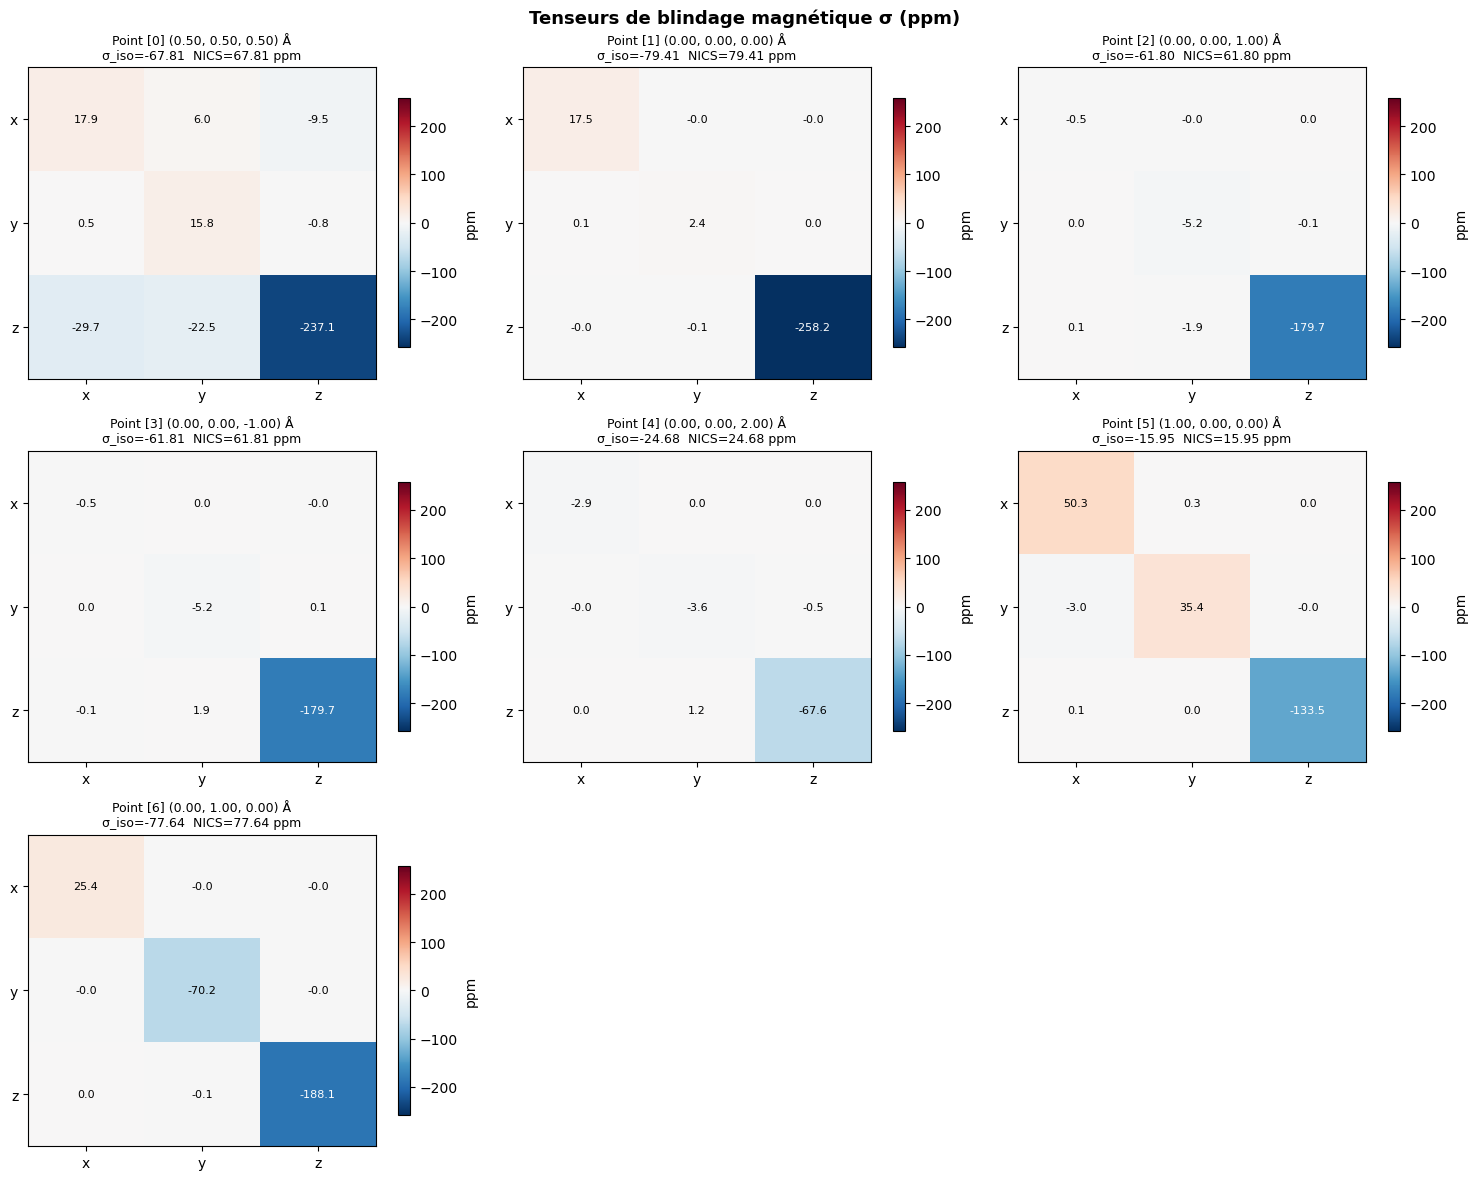

Figure sauvegardée : tenseurs_blindage.png


In [15]:
n_pts = len(results)
ncols = min(3, n_pts)
nrows = (n_pts + ncols - 1) // ncols

fig2, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).flatten() if n_pts > 1 else [axes]

vmax_tensor = max(abs(r['tensor']).max() for r in results)

for i, r in enumerate(results):
    ax = axes[i]
    im = ax.imshow(r['tensor'], cmap='RdBu_r',
                   vmin=-vmax_tensor, vmax=vmax_tensor, aspect='auto')
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['x', 'y', 'z'])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['x', 'y', 'z'])
    ax.set_title(f"Point [{i}] ({r['x']:.2f}, {r['y']:.2f}, {r['z']:.2f}) Å\n"
                 f"σ_iso={r['sigma_iso']:.2f}  NICS={r['NICS']:.2f} ppm",
                 fontsize=9)
    for ii in range(3):
        for jj in range(3):
            ax.text(jj, ii, f"{r['tensor'][ii, jj]:.1f}",
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(r['tensor'][ii, jj]) > vmax_tensor*0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8, label='ppm')

# Masquer les axes vides
for i in range(len(results), len(axes)):
    axes[i].set_visible(False)

fig2.suptitle('Tenseurs de blindage magnétique σ (ppm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tenseurs_blindage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : tenseurs_blindage.png')

## 11. Export des résultats

In [16]:
# Export CSV
df.to_csv('shielding_results.csv', index=False)
print('Résultats exportés dans : shielding_results.csv')

# Export des tenseurs complets (numpy)
tensors_array = np.array([r['tensor'] for r in results])  # shape (N, 3, 3)
np.save('shielding_tensors.npy', tensors_array)
print(f'Tenseurs exportés dans : shielding_tensors.npy  (shape = {tensors_array.shape})')

# Résumé final
print('\n' + '='*50)
print('RÉSUMÉ FINAL')
print('='*50)
for r in results:
    print(f"  Point [{r['point_idx']}] ({r['x']:.2f}, {r['y']:.2f}, {r['z']:.2f}) Å"
          f" → NICS = {r['NICS']:+.2f} ppm  |  NICS_zz = {r['NICS_zz']:+.2f} ppm")

Résultats exportés dans : shielding_results.csv
Tenseurs exportés dans : shielding_tensors.npy  (shape = (7, 3, 3))

RÉSUMÉ FINAL
  Point [0] (0.50, 0.50, 0.50) Å → NICS = +67.81 ppm  |  NICS_zz = +237.11 ppm
  Point [1] (0.00, 0.00, 0.00) Å → NICS = +79.41 ppm  |  NICS_zz = +258.20 ppm
  Point [2] (0.00, 0.00, 1.00) Å → NICS = +61.80 ppm  |  NICS_zz = +179.70 ppm
  Point [3] (0.00, 0.00, -1.00) Å → NICS = +61.81 ppm  |  NICS_zz = +179.74 ppm
  Point [4] (0.00, 0.00, 2.00) Å → NICS = +24.68 ppm  |  NICS_zz = +67.55 ppm
  Point [5] (1.00, 0.00, 0.00) Å → NICS = +15.95 ppm  |  NICS_zz = +133.49 ppm
  Point [6] (0.00, 1.00, 0.00) Å → NICS = +77.64 ppm  |  NICS_zz = +188.12 ppm


## 12. Utilisation avec un fichier de points externe

Pour utiliser ce notebook avec votre propre liste de points, créez un fichier texte `points.xyz` avec le format suivant :

```
# x       y       z       (en Angström, commentaires commençant par #)
  0.5     0.5     0.5
  0.0     0.0     0.0
  0.0     0.0     1.0
  ...
```

Puis dans la cellule 3, remplacez la définition manuelle par :

```python
points_ang = np.loadtxt('points.xyz', comments='#')
```

Le reste du notebook fonctionne sans modification.

---

## Références

- **NICS** : Schleyer et al., *J. Am. Chem. Soc.* **1996**, 118, 6317.
- **GIAO** : Wolinski et al., *J. Am. Chem. Soc.* **1990**, 112, 8251.
- **PySCF** : Sun et al., *WIREs Comput. Mol. Sci.* **2018**, 8, e1340.